In [8]:
# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, roc_curve, confusion_matrix, roc_auc_score
import numpy as np

In [9]:
# Loading dataset and display first few data
dataset = pd.read_csv("../../Data/Churn Prediction Data/churn-bigml-80.csv")
print(dataset.head())

  State  Account length  Area code International plan Voice mail plan  \
0    KS             128        415                 No             Yes   
1    OH             107        415                 No             Yes   
2    NJ             137        415                 No              No   
3    OH              84        408                Yes              No   
4    OK              75        415                Yes              No   

   Number vmail messages  Total day minutes  Total day calls  \
0                     25              265.1              110   
1                     26              161.6              123   
2                      0              243.4              114   
3                      0              299.4               71   
4                      0              166.7              113   

   Total day charge  Total eve minutes  Total eve calls  Total eve charge  \
0             45.07              197.4               99             16.78   
1             27.47   

In [10]:
# Display all details of dataset
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2666 entries, 0 to 2665
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   2666 non-null   object 
 1   Account length          2666 non-null   int64  
 2   Area code               2666 non-null   int64  
 3   International plan      2666 non-null   object 
 4   Voice mail plan         2666 non-null   object 
 5   Number vmail messages   2666 non-null   int64  
 6   Total day minutes       2666 non-null   float64
 7   Total day calls         2666 non-null   int64  
 8   Total day charge        2666 non-null   float64
 9   Total eve minutes       2666 non-null   float64
 10  Total eve calls         2666 non-null   int64  
 11  Total eve charge        2666 non-null   float64
 12  Total night minutes     2666 non-null   float64
 13  Total night calls       2666 non-null   int64  
 14  Total night charge      2666 non-null   

In [11]:
print(dataset.isna().sum())

State                     0
Account length            0
Area code                 0
International plan        0
Voice mail plan           0
Number vmail messages     0
Total day minutes         0
Total day calls           0
Total day charge          0
Total eve minutes         0
Total eve calls           0
Total eve charge          0
Total night minutes       0
Total night calls         0
Total night charge        0
Total intl minutes        0
Total intl calls          0
Total intl charge         0
Customer service calls    0
Churn                     0
dtype: int64


In [12]:
print(dataset.duplicated().sum())

0


In [13]:
# Converting categorical data into numerical data
dataset['International plan'] = dataset['International plan'].map({'No':0, 'Yes':1})
dataset['Voice mail plan'] = dataset['Voice mail plan'].map({'No':0, 'Yes':1})
dataset = pd.get_dummies(dataset, columns=['State'], drop_first=True).astype(int)
print(dataset.head())

   Account length  Area code  International plan  Voice mail plan  \
0             128        415                   0                1   
1             107        415                   0                1   
2             137        415                   0                0   
3              84        408                   1                0   
4              75        415                   1                0   

   Number vmail messages  Total day minutes  Total day calls  \
0                     25                265              110   
1                     26                161              123   
2                      0                243              114   
3                      0                299               71   
4                      0                166              113   

   Total day charge  Total eve minutes  Total eve calls  ...  State_SD  \
0                45                197               99  ...         0   
1                27                195              

In [14]:
# Rearranging columns
cols = ["Churn"]
dataset = dataset[cols + [col for col in dataset.columns if col not in cols]]
print(dataset.head())

   Churn  Account length  Area code  International plan  Voice mail plan  \
0      0             128        415                   0                1   
1      0             107        415                   0                1   
2      0             137        415                   0                0   
3      0              84        408                   1                0   
4      0              75        415                   1                0   

   Number vmail messages  Total day minutes  Total day calls  \
0                     25                265              110   
1                     26                161              123   
2                      0                243              114   
3                      0                299               71   
4                      0                166              113   

   Total day charge  Total eve minutes  ...  State_SD  State_TN  State_TX  \
0                45                197  ...         0         0         0   
1   

In [15]:
# Feature Selection
data = dataset.values
X = data[:, 1:]
y = data[:, 0]
print(X.shape)
print(y.shape)

(2666, 68)
(2666,)


In [16]:
# Splitting of dataset into training and testing sets
# 80/20 ratio
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1, stratify=y)

In [17]:
# Display training and testing sets shape
print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(2132, 68) (534, 68)
(2132,) (534,)


In [18]:
# Feature Scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [19]:
# Logistic Regression model
lr = LogisticRegression()

# Model fitting
lr.fit(X_train, y_train)


LogisticRegression()

In [20]:
# Coefficient and Odds ratio
print("Coefficients:",lr.coef_)
print()
print("Odds Ratio:",np.exp(lr.coef_))

Coefficients: [[ 0.11574951 -0.05952345  0.69306493 -0.61672971  0.20435272  0.31893822
   0.13532448  0.45198243 -0.26736557 -0.09016143  0.5794612   1.11249163
   0.03578259 -0.99115385  0.208382   -0.2717593   0.08984656  0.75002382
   0.02828883  0.10544964  0.06362367  0.07740821  0.0222043   0.16553194
   0.08566185  0.12029501  0.02976386  0.09712742 -0.12172588  0.05277374
   0.03763287 -0.06966802  0.0136838   0.09088916  0.04286921  0.03732554
   0.12078345  0.08387651  0.19942185  0.09703277  0.18452598  0.0492131
   0.13476848  0.18810682  0.04166899 -0.09501567  0.05379751  0.1475114
   0.09631959 -0.04544761  0.16352999  0.1150265   0.08912712  0.06852023
   0.00320577  0.15325087 -0.12115033  0.2313644   0.08554449 -0.01837166
   0.28156887  0.16232848 -0.07725162 -0.04425228  0.13535804 -0.11796692
   0.02701318  0.02041181]]

Odds Ratio: [[1.1227146  0.94221344 1.9998355  0.53970655 1.22673077 1.37566633
  1.14490822 1.57142434 0.76539322 0.91378367 1.78507637 3.041928

coefficient of the feature tells us the prediction and movement towards postivite class. Positive coef means prediction moving towards positive class and negative moving away from positive class.

odds ratio is e to power of coef . It tells the for every 1 unit increase in feature, the odds of the positive class are multiplied by odds ratio value, assuming all other features stay constant.

- '>1' - increases the odds of the positive class
- '=1' - no effect
- '<1' - decreases the odds of the positive class

In [21]:
# Labels and churn
names = ['No Churn', 'Churn']
labels = [0, 1]

Accuracy:85.39%
              precision    recall  f1-score   support

    No Churn       0.88      0.96      0.92       456
       Churn       0.50      0.21      0.29        78

    accuracy                           0.85       534
   macro avg       0.69      0.59      0.60       534
weighted avg       0.82      0.85      0.83       534



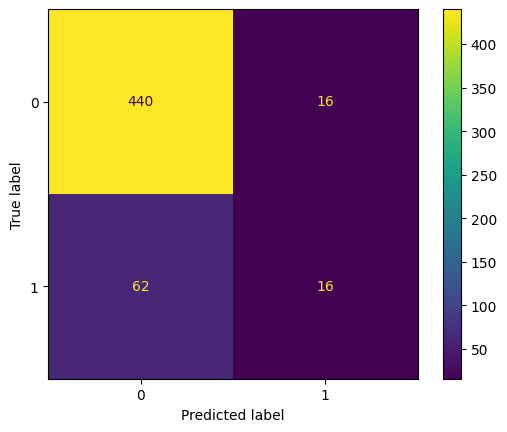

In [22]:
# Prediction by Logistic Regression model
y_pred = lr.predict(X_test)

# Metrics
print(f"Accuracy:{lr.score(X_test, y_test) * 100 :.2f}%")

print(classification_report(y_test, y_pred,target_names=names ))

cm = confusion_matrix(y_test, y_pred,labels=labels)
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.show()

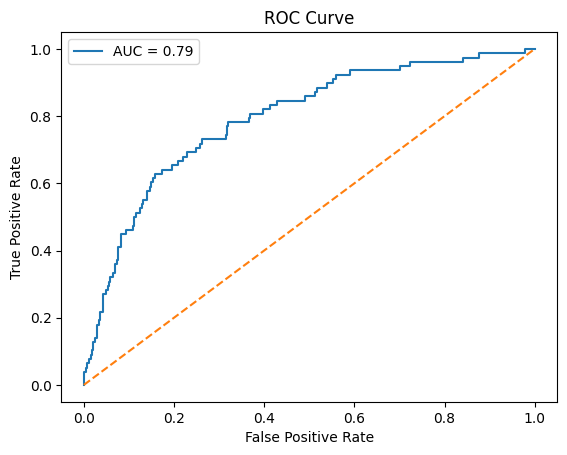

In [23]:
# ROC Curve
y_prob = lr.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

auc_score = roc_auc_score(y_test, y_prob)

plt.plot(fpr, tpr, label=f'AUC = {auc_score:.2f}')
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()

plt.show()